# Compiler-matched CPU/GPU crossover atlas

## tl;dr

This notebook analyzes the frozen pilots 003/004: 2,304 raw timing
observations over 256 hardware/case cells on a local GTX 1660 Ti and ephemeral
Modal L4. CPU and GPU execute the same static-shape rollout through
`torch.compile(fullgraph=True, dynamic=False)`; every timed repetition advances
all agents by exactly 64 transitions.

The main result is a three-way boundary:

- **residency/fusion:** compiling 64 transitions into one resident call moves
  every valid stratum above the faster one- or eight-thread compiled CPU by the
  smallest tested population (`N=256`) on both GPUs;
- **hardware:** at `H=1`, L4 crosses the tuned CPU by `N=256` in every valid
  stratum, while the GTX 1660 Ti needs 4,096 or 65,536 in several strata and
  has no valid win in one wide/branchy stratum;
- **correctness:** 9 of 32 shapes are excluded on both machines because small
  CPU/CUDA floating differences cross discrete action thresholds and alter the
  trajectory. The failures are identical across hardware and remain in the
  raw ledgers.

## Context & Methods

The transition scores dense float32 state, assigns a discrete action, applies
an action-specific state update, and updates a budget. `H=1` invokes a compiled
one-step graph 64 times; `H=64` invokes one compiled 64-step graph. Resident GPU
state stays on device. Host-visible mode copies final actions to CPU after each
compiled call (64 copies for `H=1`, one for `H=64`).

The preregistered primary comparator is the eight-thread compiled CPU. Because
threading overhead makes one thread faster in many small cells, this notebook
also reports a more conservative deployment comparator: the faster median of
the one- and eight-thread CPU cells at each shape. No timing observation is
deleted. Ratio intervals are independent percentile bootstraps of the two
cell medians and are descriptive because repetitions evolve one persistent
state trajectory.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter, LogLocator

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data/processed"
FIGURE_DIR = ROOT / "results/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cells = pd.read_csv(PROCESSED_DIR / "compiler-matched-cell-summary.csv")
speedups = pd.read_csv(PROCESSED_DIR / "compiler-matched-speedups.csv")
crossovers = pd.read_csv(PROCESSED_DIR / "compiler-matched-crossovers.csv")
shape_quality = pd.read_csv(PROCESSED_DIR / "compiler-matched-shape-quality.csv")
run_quality = pd.read_csv(PROCESSED_DIR / "compiler-matched-run-quality.csv")
manifest = json.loads(
    (PROCESSED_DIR / "compiler-matched-analysis-manifest.json").read_text()
)

sns.set_theme(style="whitegrid", context="notebook")
HARDWARE_ORDER = ["NVIDIA GeForce GTX 1660 Ti", "NVIDIA L4"]
SHAPE_STYLE = {
    (8, 1): {"label": "W=8, A=1", "color": "#0B6E75", "marker": "o"},
    (8, 8): {"label": "W=8, A=8", "color": "#D97706", "marker": "s"},
    (32, 1): {"label": "W=32, A=1", "color": "#2563EB", "marker": "^"},
    (32, 8): {"label": "W=32, A=8", "color": "#7C3AED", "marker": "D"},
}

len(cells), len(speedups), len(shape_quality), run_quality

(256,
 128,
 64,
                                          source_file            run_id  \
 0  pilot-003-local-compiler-matched-20260811T1548...  20260811T154807Z   
 1  pilot-004-modal-l4-compiler-matched-20260811T1...  20260811T162615Z   
 
                      hardware provider  rows  cases  execution_error_rows  \
 0  NVIDIA GeForce GTX 1660 Ti    local  1152    128                     0   
 1                   NVIDIA L4    modal  1152    128                     0   
 
    duplicate_case_repetitions  shapes  invalid_shapes  median_cell_cv  \
 0                           0      32               9        0.023188   
 1                           0      32               9        0.025873   
 
    p90_cell_cv  cells_cv_over_10pct  
 0     0.260384                   28  
 1     0.129735                   18  )

## Data quality and exclusions

In [2]:
assert (run_quality["rows"] == 1152).all()
assert (run_quality["cases"] == 128).all()
assert (run_quality["execution_error_rows"] == 0).all()
assert (run_quality["duplicate_case_repetitions"] == 0).all()
assert (run_quality["invalid_shapes"] == 9).all()
assert set(cells["observations"]) == {9}

run_quality[
    [
        "hardware",
        "rows",
        "cases",
        "shapes",
        "invalid_shapes",
        "median_cell_cv",
        "p90_cell_cv",
        "cells_cv_over_10pct",
    ]
]

,hardware,rows,cases,shapes,invalid_shapes,median_cell_cv,p90_cell_cv,cells_cv_over_10pct
0,NVIDIA GeForce GTX 1660 Ti,1152,128,32,9,0.023188,0.260384,28
1,NVIDIA L4,1152,128,32,9,0.025873,0.129735,18


In [3]:
invalid_shapes = shape_quality[~shape_quality["shape_valid"]][
    [
        "hardware",
        "agent_count",
        "state_width",
        "action_count",
        "observation_horizon",
        "action_match",
        "max_state_abs_error",
        "max_budget_abs_error",
    ]
].sort_values(["hardware", "agent_count", "state_width", "observation_horizon"])
invalid_shapes

,hardware,agent_count,state_width,action_count,observation_horizon,action_match,max_state_abs_error,max_budget_abs_error
14,NVIDIA GeForce GTX 1660 Ti,4096,32,8,1,True,0.000034,0.107151
18,NVIDIA GeForce GTX 1660 Ti,65536,8,8,1,False,0.000055,0.107147
19,NVIDIA GeForce GTX 1660 Ti,65536,8,8,64,False,0.000055,0.107147
22,NVIDIA GeForce GTX 1660 Ti,65536,32,8,1,True,0.000028,0.107147
23,NVIDIA GeForce GTX 1660 Ti,65536,32,8,64,False,0.000028,0.107147
26,NVIDIA GeForce GTX 1660 Ti,1048576,8,8,1,False,0.000059,0.107147
27,NVIDIA GeForce GTX 1660 Ti,1048576,8,8,64,False,0.000059,0.107147
30,NVIDIA GeForce GTX 1660 Ti,1048576,32,8,1,False,0.000042,0.107147
31,NVIDIA GeForce GTX 1660 Ti,1048576,32,8,64,False,0.000042,0.107147
46,NVIDIA L4,4096,32,8,1,True,0.000034,0.107151


All invalid shapes have `A=8`. The largest state discrepancy is only about
`5.9e-5`, but a changed threshold decision alters one or more action costs and
produces a budget difference near `0.107`. Final actions can reconverge even
after the trajectory differed, so exact action equality at only the final step
is not by itself a sufficient correctness diagnostic. Confirmatory kernels
should use integer state or record per-step decision margins and divergence.

## Results: steady-state crossover

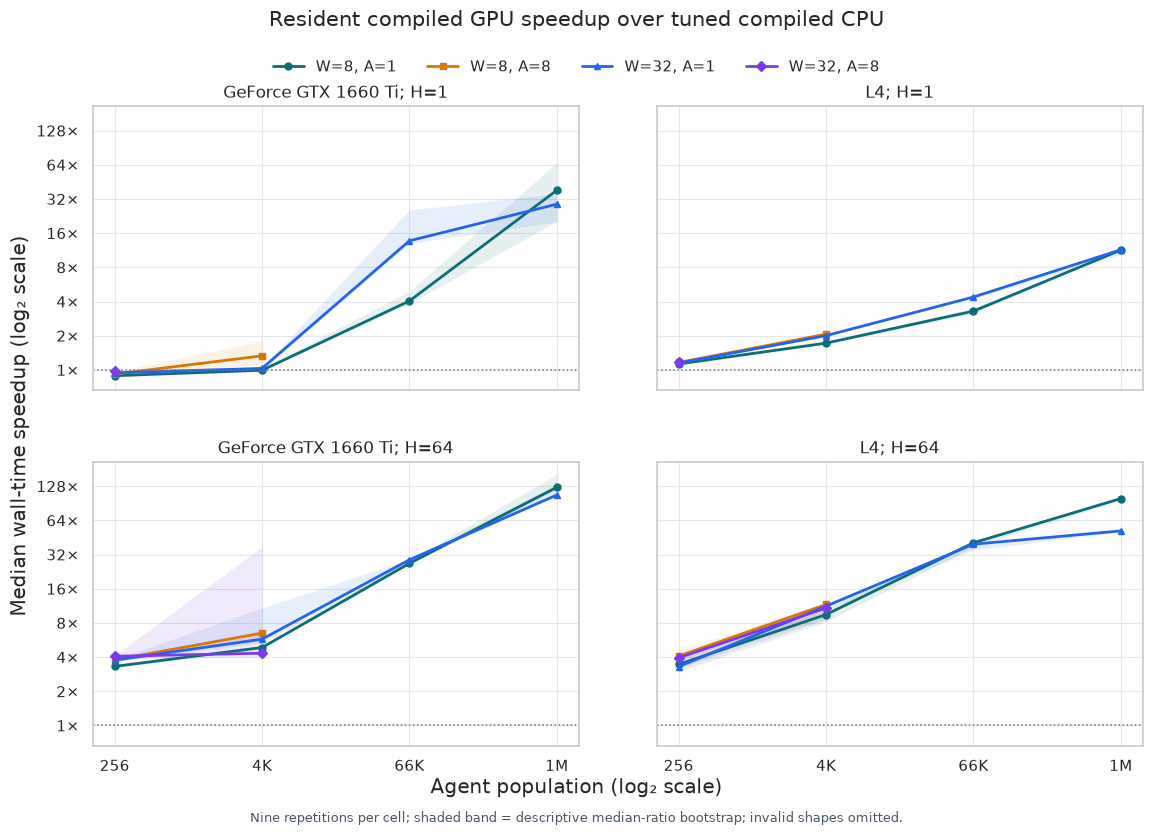

In [4]:
resident = speedups[
    (speedups["mode"] == "compiled-gpu-resident") & speedups["shape_valid"]
].copy()

def population_label(value, _position):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.0f}M"
    if value >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:g}"


def speedup_label(value, _position):
    return f"{value:g}×"


fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.0), sharex=True, sharey=True)
for row_index, horizon in enumerate([1, 64]):
    for column_index, hardware in enumerate(HARDWARE_ORDER):
        axis = axes[row_index, column_index]
        panel = resident[
            (resident["hardware"] == hardware)
            & (resident["observation_horizon"] == horizon)
        ]
        for (state_width, action_count), style in SHAPE_STYLE.items():
            series = panel[
                (panel["state_width"] == state_width)
                & (panel["action_count"] == action_count)
            ].sort_values("agent_count")
            if series.empty:
                continue
            axis.plot(
                series["agent_count"],
                series["speedup_vs_best_cpu"],
                marker=style["marker"],
                color=style["color"],
                linewidth=2.0,
                markersize=5,
                label=style["label"],
            )
            axis.fill_between(
                series["agent_count"],
                series["speedup_vs_best_cpu_bootstrap_ci_low"],
                series["speedup_vs_best_cpu_bootstrap_ci_high"],
                color=style["color"],
                alpha=0.10,
                linewidth=0,
            )
        axis.axhline(1.0, color="#6B7280", linewidth=1.1, linestyle=":")
        axis.set_xscale("log", base=2)
        axis.set_yscale("log", base=2)
        axis.set_xticks([256, 4096, 65536, 1048576])
        axis.set_title(f"{hardware.replace('NVIDIA ', '')}; H={horizon}")
        axis.xaxis.set_major_formatter(FuncFormatter(population_label))
        axis.yaxis.set_major_locator(LogLocator(base=2, numticks=10))
        axis.yaxis.set_major_formatter(FuncFormatter(speedup_label))
        axis.grid(True, which="major", color="#E5E7EB", linewidth=0.8)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.975))
fig.suptitle("Resident compiled GPU speedup over tuned compiled CPU", y=1.02, fontsize=15)
fig.supxlabel("Agent population (log₂ scale)", y=0.035)
fig.supylabel("Median wall-time speedup (log₂ scale)", x=0.02)
fig.text(
    0.5,
    0.005,
    "Nine repetitions per cell; shaded band = descriptive median-ratio bootstrap; invalid shapes omitted.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.10, top=0.90, hspace=0.25, wspace=0.16)
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURE_DIR / f"compiler-matched-resident-speedup.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [5]:
resident_crossovers = crossovers[crossovers["mode"] == "compiled-gpu-resident"][
    [
        "hardware",
        "state_width",
        "action_count",
        "observation_horizon",
        "smallest_tested_crossover_n_cpu8",
        "smallest_tested_crossover_n_best_cpu",
        "max_valid_speedup_best_cpu",
        "valid_populations",
    ]
].sort_values(["hardware", "observation_horizon", "state_width", "action_count"])
resident_crossovers

,hardware,state_width,action_count,observation_horizon,smallest_tested_crossover_n_cpu8,smallest_tested_crossover_n_best_cpu,max_valid_speedup_best_cpu,valid_populations
1,NVIDIA GeForce GTX 1660 Ti,8,1,1,256.0,65536.0,38.126469,4.0
5,NVIDIA GeForce GTX 1660 Ti,8,8,1,4096.0,4096.0,1.330250,2.0
9,NVIDIA GeForce GTX 1660 Ti,32,1,1,256.0,4096.0,28.789958,4.0
13,NVIDIA GeForce GTX 1660 Ti,32,8,1,NaN,NaN,0.978877,1.0
3,NVIDIA GeForce GTX 1660 Ti,8,1,64,256.0,256.0,124.928026,4.0
7,NVIDIA GeForce GTX 1660 Ti,8,8,64,256.0,256.0,6.505068,2.0
11,NVIDIA GeForce GTX 1660 Ti,32,1,64,256.0,256.0,106.906537,4.0
15,NVIDIA GeForce GTX 1660 Ti,32,8,64,256.0,256.0,4.327236,2.0
17,NVIDIA L4,8,1,1,256.0,256.0,11.348172,4.0
21,NVIDIA L4,8,8,1,256.0,256.0,2.063055,2.0


The fixed eight-thread baseline overstates several small-population GTX wins.
Against the tuned CPU, GTX `H=1` crosses at 65,536 for `W=8,A=1`, at 4,096
for `W=8,A=8` and `W=32,A=1`, and not in the sole valid `W=32,A=8`
population. L4 remains above the tuned CPU at `N=256` in every valid stratum,
but the true crossover may lie below the tested grid; pilots 005/006 refine
that boundary.

## Temporal fusion and host observation

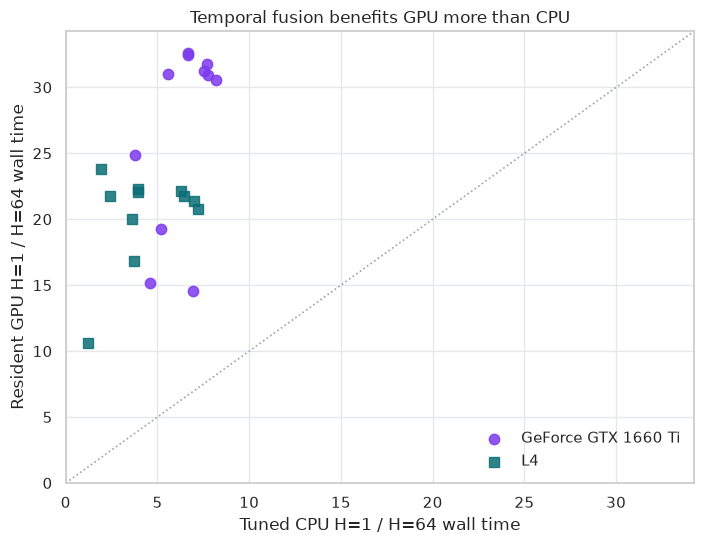

,min,median,max
hardware,,,
NVIDIA GeForce GTX 1660 Ti,2.099343,4.119522,6.614595
NVIDIA L4,2.874841,5.500846,12.325242


In [6]:
index_columns = ["hardware", "agent_count", "state_width", "action_count"]

best_cpu = (
    cells[cells["mode"] == "compiled-cpu"]
    .sort_values("wall_ms_median")
    .groupby([*index_columns, "observation_horizon"], as_index=False)
    .first()
)
cpu_horizon = best_cpu.pivot(
    index=index_columns, columns="observation_horizon", values="wall_ms_median"
).dropna()
gpu_horizon = cells[
    (cells["mode"] == "compiled-gpu-resident") & cells["shape_valid"]
].pivot(index=index_columns, columns="observation_horizon", values="wall_ms_median").dropna()
fusion = pd.DataFrame(
    {
        "cpu_fusion_gain": cpu_horizon[1] / cpu_horizon[64],
        "gpu_fusion_gain": gpu_horizon[1] / gpu_horizon[64],
    }
).dropna()
fusion["gpu_over_cpu_fusion_gain"] = fusion["gpu_fusion_gain"] / fusion["cpu_fusion_gain"]
fusion = fusion.reset_index()

fig, axis = plt.subplots(figsize=(7.2, 5.6))
for hardware, color, marker in [
    ("NVIDIA GeForce GTX 1660 Ti", "#7C3AED", "o"),
    ("NVIDIA L4", "#0B6E75", "s"),
]:
    panel = fusion[fusion["hardware"] == hardware]
    axis.scatter(
        panel["cpu_fusion_gain"],
        panel["gpu_fusion_gain"],
        s=56,
        alpha=0.85,
        color=color,
        marker=marker,
        label=hardware.replace("NVIDIA ", ""),
    )
limit = max(fusion["gpu_fusion_gain"].max(), fusion["cpu_fusion_gain"].max()) * 1.05
axis.plot([0, limit], [0, limit], color="#9CA3AF", linestyle=":", linewidth=1.2)
axis.set_xlim(0, limit)
axis.set_ylim(0, limit)
axis.set_xlabel("Tuned CPU H=1 / H=64 wall time")
axis.set_ylabel("Resident GPU H=1 / H=64 wall time")
axis.set_title("Temporal fusion benefits GPU more than CPU")
axis.legend(frameon=False)
axis.grid(True, color="#E5E7EB")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURE_DIR / f"compiler-matched-temporal-fusion.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

fusion.groupby("hardware")["gpu_over_cpu_fusion_gain"].agg(["min", "median", "max"])

In [7]:
resident_times = speedups[speedups["mode"] == "compiled-gpu-resident"][
    [
        "hardware",
        "agent_count",
        "state_width",
        "action_count",
        "observation_horizon",
        "wall_ms_median",
        "shape_valid",
    ]
].rename(columns={"wall_ms_median": "resident_ms"})
host_times = speedups[speedups["mode"] == "compiled-gpu-host-visible"][
    [
        "hardware",
        "agent_count",
        "state_width",
        "action_count",
        "observation_horizon",
        "wall_ms_median",
    ]
].rename(columns={"wall_ms_median": "host_visible_ms"})
host_penalty = resident_times.merge(
    host_times,
    on=["hardware", "agent_count", "state_width", "action_count", "observation_horizon"],
)
host_penalty["host_visibility_penalty"] = (
    host_penalty["host_visible_ms"] / host_penalty["resident_ms"]
)
host_penalty[host_penalty["shape_valid"]].groupby(
    ["hardware", "observation_horizon"]
)["host_visibility_penalty"].agg(["median", "min", "max"])

median       min       max
hardware                   observation_horizon                              
NVIDIA GeForce GTX 1660 Ti 1                    1.361225  1.277085  3.326978
                           64                   1.224290  1.155137  1.563989
NVIDIA L4                  1                    1.595382  1.483734  6.961611
                           64                   1.214759  1.107138  2.115717

## Compilation amortization and timing stability

In [8]:
compile_cells = cells.assign(
    backend=np.where(cells["mode"] == "compiled-cpu", "cpu", "cuda")
)
compile_ranges = compile_cells.groupby(["hardware", "backend", "observation_horizon"])[
    "compile_first_call_ms"
].agg(["min", "median", "max"])
compile_ranges

min  \
hardware                   backend observation_horizon                 
NVIDIA GeForce GTX 1660 Ti cpu     1                      661.245790   
                                   64                   12654.123936   
                           cuda    1                      570.182275   
                                   64                    9363.569816   
NVIDIA L4                  cpu     1                     1676.246140   
                                   64                   29142.308022   
                           cuda    1                     1507.015436   
                                   64                   23291.303409   

                                                              median  \
hardware                   backend observation_horizon                 
NVIDIA GeForce GTX 1660 Ti cpu     1                      690.333045   
                                   64                   13287.525959   
                           cuda    1                      690.812791   
                                   64                   11999.557058   
NVIDIA L4                  cpu     1                     1786.746809   
                                   64                   32281.970948   
                           cuda    1                     2051.020161   
                                   64                   29084.701795   

                                                                 max  
hardware                   backend observation_horizon                
NVIDIA GeForce GTX 1660 Ti cpu     1                      785.217778  
                                   64                   17248.722439  
                           cuda    1                     1244.097745  
                                   64                   18600.687672  
NVIDIA L4                  cpu     1                     2459.418878  
                                   64                   68130.156162  
                           cuda    1                     3000.404160  
                                   64                   42926.988241

In [9]:
break_even = resident[
    [
        "hardware",
        "agent_count",
        "state_width",
        "action_count",
        "observation_horizon",
        "speedup_vs_best_cpu",
        "extra_compile_ms_vs_cpu",
        "break_even_rollouts_best_cpu",
        "stable_under_10pct_cv",
    ]
].sort_values("break_even_rollouts_best_cpu", ascending=False)
break_even.head(15)

,hardware,agent_count,state_width,action_count,observation_horizon,speedup_vs_best_cpu,extra_compile_ms_vs_cpu,break_even_rollouts_best_cpu,stable_under_10pct_cv
31,NVIDIA GeForce GTX 1660 Ti,4096,32,8,64,4.327236,4226.777425,4990.480662,False
7,NVIDIA GeForce GTX 1660 Ti,256,8,8,64,3.782954,1406.020478,3167.997111,True
15,NVIDIA GeForce GTX 1660 Ti,256,32,8,64,4.069141,1343.941967,2784.010240,False
73,NVIDIA L4,256,32,1,1,1.149739,1016.535889,858.478060,True
23,NVIDIA GeForce GTX 1660 Ti,4096,8,8,64,6.505068,636.737009,754.901785,True
77,NVIDIA L4,256,32,8,1,1.171367,532.367167,380.348384,True
69,NVIDIA L4,256,8,8,1,1.162186,489.554105,378.334096,True
65,NVIDIA L4,256,8,1,1,1.129107,251.728664,249.184737,True
81,NVIDIA L4,4096,8,1,1,1.721334,880.118128,155.436963,True
85,NVIDIA L4,4096,8,8,1,2.063055,341.307318,40.220658,True


Cold compilation is not a footnote: `H=64` first calls take seconds to tens of
seconds. The most marginal small-L4 wins require hundreds of repeated
64-transition rollouts to repay extra GPU compile time when GPU compilation is
slower than CPU compilation. Long-lived, shape-stable resident swarms can
amortize that cost; rapidly changing policies or shapes may not.

## Takeaways

1. **A GPU can act like a high-throughput control engine, not like a bag of
   cheap general-purpose CPU cores.** The win requires regular tensor work and
   resident state; whole-horizon fusion is the strongest lever measured.
2. **Temporal fusion is disproportionately valuable on GPU.** Across paired
   valid shapes, its gain relative to the tuned CPU fusion gain is 2.10–6.61×
   on the GTX 1660 Ti and 4.11–12.33× on L4.
3. **Observation frequency moves the boundary.** The median host-visibility
   penalty at `H=1` is 1.36× locally and 1.60× on L4; one-copy `H=64` reduces
   those medians to about 1.22× on both.
4. **Correctness is a first-class systems boundary.** A float error far below
   one basis point can change a discrete action and accumulate a much larger
   budget discrepancy. Confirmatory work must report trajectory divergence,
   not merely final tensor closeness.
5. **The current CPU comparison is matched at framework/compiler level, not an
   optimized CPU hardware ceiling.** The next confirmatory implementation
   needs a vectorized C++/OpenMP or equivalent CPU baseline, a deterministic
   transition, and power/cost measurements.
6. **Hardware crossover alone is insufficient.** The trace replay notebook
   shows whether real asynchronous workloads can assemble same-route ready
   cohorts at the measured `K` within a latency budget. The combined object is
   the readiness–regularity–residency frontier.